# GluonTS API Tutorial: Time Series Forecasting

**Welcome!** This notebook teaches you how to use GluonTS for time series forecasting.

## What You'll Learn

- How to configure and train three different GluonTS models
- When to use each model for your forecasting problem  
- Key parameters and their effects on predictions
- How to generate probabilistic forecasts with uncertainty

## The Three Models

We'll explore three powerful forecasting models using real COVID-19 data:

1. **DeepAR** - For complex temporal patterns (multiple waves, seasonality)
2. **SimpleFeedForward** - Fast baseline for stable trends
3. **DeepNPTS** - Flexible for changing distributions

## Why COVID-19 Data?

COVID-19 case data is perfect for learning time series forecasting because it has:
- Multiple waves (complex patterns)
- Weekly seasonality (lower reporting on weekends)
- External factors (mobility, policy changes)
- Real-world impact (resource planning matters!)

Let's dive in! 🚀

## Setup

First, let's import everything we need and load the COVID-19 data.

### Import Required Modules

In [1]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# GluonTS models
from gluonts.torch.model.deepar import DeepAREstimator
from gluonts.torch.model.simple_feedforward import SimpleFeedForwardEstimator
from gluonts.torch.model.deep_npts import DeepNPTSEstimator
from gluonts.evaluation import make_evaluation_predictions

# Our custom utilities
from GluonTS_utils_notebook_loader import quick_load_minimal
from GluonTS_utils_evaluation import calculate_metrics, plot_forecast

print("✓ All imports successful!")

✓ All imports successful!


/usr/local/lib/python3.10/site-packages/gluonts/json.py:101: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(


### Load COVID-19 Data

We'll use our quick loader to get US COVID-19 data ready for GluonTS. This gives us:
- Daily COVID-19 cases (our target to forecast)
- Deaths data (helps predict case trends)
- Google mobility data (captures behavioral changes)

The data is already preprocessed and split into training/testing sets.

In [2]:
# Load data - this does everything: load, preprocess, split, format for GluonTS
data = quick_load_minimal()

# Extract what we need
train_ds = data['train_ds']
test_ds = data['test_ds']
train_df = data['train_df']
test_df = data['test_df']
num_features = len(data['features'])

print(f"\n📊 Data Summary:")
print(f"  Training period: {data['info']['train_days']} days")
print(f"  Testing period: {data['info']['test_days']} days")
print(f"  Target: {data['target']}")
print(f"  Features: {num_features} ({', '.join(data['features'])})")

COVID-19 DATA LOADER

📥 Loading raw data...
Loading cases data from data/cases.csv
✓ Loaded 3342 rows, 1154 columns
Loading deaths data from data/deaths.csv
✓ Loaded 3342 rows, 1155 columns
Loading mobility data from data/mobility.csv
✓ Loaded 1847210 rows, 9 columns
  Date range: 2020-02-15 00:00:00 to 2022-02-01 00:00:00
✓ Data files loaded successfully (cases, deaths, mobility)

🔧 Preprocessing...

🔗 Merging data sources...
✓ Merged data: 1143 days
  Date range: 2020-01-22 to 2023-03-09

🎯 Feature selection: minimal
  Selected 3 features:
    1. Daily_Deaths_MA7
    2. Cumulative_Deaths
    3. CFR

✂️  Splitting data (test size: 14 days)...

Train/Test Split:
  Train: 1123 days (2020-01-28 to 2023-02-23)
  Test:  14 days (2023-02-24 to 2023-03-09)

🔄 Converting to GluonTS format...
✓ GluonTS datasets created
  Note: Test dataset contains full time series (train + test periods)

✅ DATA READY FOR TRAINING!

📊 Summary:
  Target: Daily_Cases_MA7
  Features: 3 (minimal)
  Train: 1123 day

### Visualize the Data

Let's see what we're working with - the full COVID-19 case history for the US.

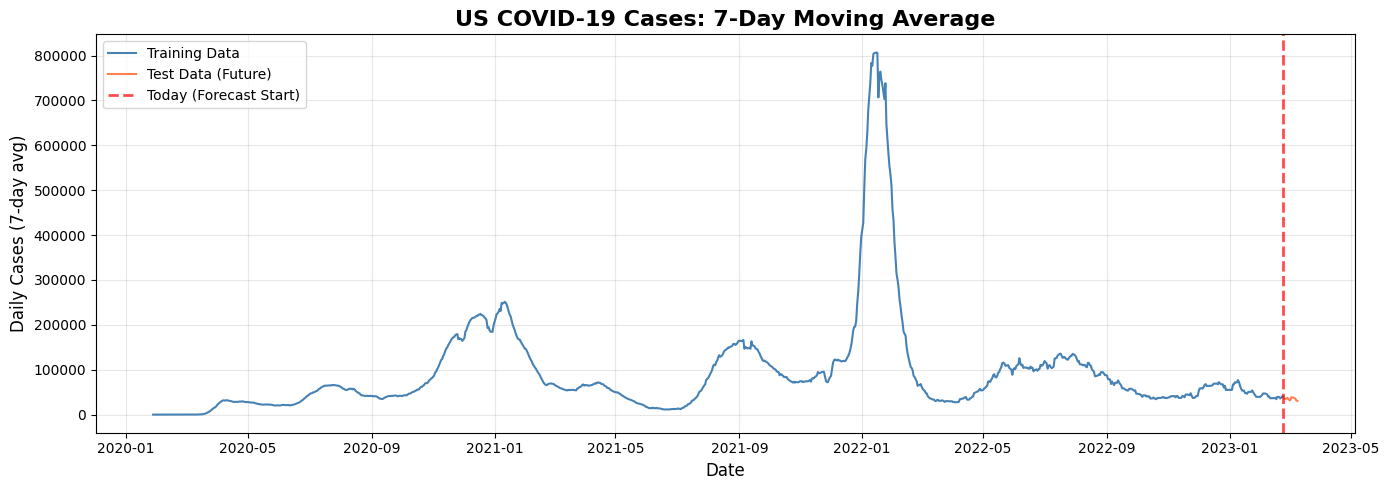


👆 Notice the multiple waves? That's what makes this interesting to forecast!


In [3]:
plt.figure(figsize=(14, 5))

# Plot training data
plt.plot(train_df['Date'], train_df[data['target']], 
         label='Training Data', color='steelblue', linewidth=1.5)

# Plot test data
plt.plot(test_df['Date'], test_df[data['target']], 
         label='Test Data (Future)', color='coral', linewidth=1.5)

plt.axvline(x=train_df['Date'].iloc[-1], color='red', 
            linestyle='--', linewidth=2, alpha=0.7, label='Today (Forecast Start)')

plt.title('US COVID-19 Cases: 7-Day Moving Average', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily Cases (7-day avg)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n👆 Notice the multiple waves? That's what makes this interesting to forecast!")

---

# Part 1: DeepAR - For Complex Patterns

DeepAR is a powerful model that uses **recurrent neural networks (RNNs)** to learn temporal dependencies. Think of it as a model that "remembers" what happened before to make better predictions.

## When to Use DeepAR

✅ Use DeepAR when you have:
- **Complex patterns** (like COVID waves)
- **Seasonality** (weekly/monthly cycles)
- **Long-term dependencies** (patterns that repeat over time)
- **Multiple related time series** (though we're using one here)

## Key Parameters

Let's understand the important configuration options:

| Parameter | What It Does | Typical Values |
|-----------|-------------|----------------|
| `prediction_length` | How many days to forecast | 7, 14, 30 |
| `context_length` | How much history to use | 2-4x prediction_length |
| `num_layers` | RNN depth (more = complex patterns) | 2-3 |
| `hidden_size` | Network capacity | 40-100 |
| `dropout_rate` | Prevents overfitting | 0.1-0.2 |
| `epochs` | Training iterations | 20-50 |
| `num_feat_dynamic_real` | Number of external features | 0-10+ |

## Configure DeepAR

In [4]:
# Let's configure DeepAR for COVID forecasting
deepar_estimator = DeepAREstimator(
    freq='D',                              # Daily data
    prediction_length=14,                  # Forecast 2 weeks ahead
    context_length=60,                     # Use 2 months of history (4x prediction length)
    num_feat_dynamic_real=num_features,    # Include our external features (deaths, mobility)
    
    # Network architecture
    num_layers=2,                          # Two RNN layers for learning patterns
    hidden_size=40,                        # Network size (bigger = more complex patterns)
    dropout_rate=0.1,                      # Regularization to prevent overfitting
    
    # Training settings
    lr=0.001,                              # Learning rate
    batch_size=32,
    num_batches_per_epoch=50,
    trainer_kwargs={"max_epochs": 10}
)

print("✓ DeepAR configured!")
print(f"\nConfiguration:")
print(f"  • Forecasting: 14 days ahead")
print(f"  • Using: 60 days of history")
print(f"  • Features: {num_features} (deaths + mobility)")
print(f"  • Network: 2 layers, size 40")
print(f"  • Training: 10 epochs (fast demo)")

✓ DeepAR configured!

Configuration:
  • Forecasting: 14 days ahead
  • Using: 60 days of history
  • Features: 3 (deaths + mobility)
  • Network: 2 layers, size 40
  • Training: 10 epochs (fast demo)


## Train DeepAR

Now let's train the model on our COVID data. This will take a minute or two.

In [5]:
print("🚀 Training DeepAR on COVID-19 data...")
print("(This uses PyTorch Lightning under the hood)\n")

# Train the model
deepar_predictor = deepar_estimator.train(train_ds)

print("\n✓ Training complete!")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


🚀 Training DeepAR on COVID-19 data...
(This uses PyTorch Lightning under the hood)




  | Name  | Type        | Params | In sizes                                                         | Out sizes   
------------------------------------------------------------------------------------------------------------------------
0 | model | DeepARModel | 26.4 K | [[1, 1], [1, 1], [1, 1152, 7], [1, 1152], [1, 1152], [1, 14, 7]] | [1, 100, 14]
------------------------------------------------------------------------------------------------------------------------
26.4 K    Trainable params
0         Non-trainable params
26.4 K    Total params
0.105     Total estimated model params size (MB)


Training: |                                                                                    | 0/? [00:00<?,…

Epoch 0, global step 50: 'train_loss' reached 11.64884 (best 11.64884), saving model to '/workspace/lightning_logs/version_4/checkpoints/epoch=0-step=50.ckpt' as top 1
Epoch 1, global step 100: 'train_loss' reached 11.23156 (best 11.23156), saving model to '/workspace/lightning_logs/version_4/checkpoints/epoch=1-step=100.ckpt' as top 1
Epoch 2, global step 150: 'train_loss' was not in top 1
Epoch 3, global step 200: 'train_loss' was not in top 1
Epoch 4, global step 250: 'train_loss' reached 11.18457 (best 11.18457), saving model to '/workspace/lightning_logs/version_4/checkpoints/epoch=4-step=250.ckpt' as top 1
Epoch 5, global step 300: 'train_loss' reached 11.12342 (best 11.12342), saving model to '/workspace/lightning_logs/version_4/checkpoints/epoch=5-step=300.ckpt' as top 1
Epoch 6, global step 350: 'train_loss' was not in top 1
Epoch 7, global step 400: 'train_loss' was not in top 1
Epoch 8, global step 450: 'train_loss' was not in top 1
Epoch 9, global step 500: 'train_loss' was


✓ Training complete!


## Generate Forecasts

DeepAR produces **probabilistic forecasts** - not just a single prediction, but a distribution of possible futures. This gives us confidence intervals!

In [6]:
print("🔮 Generating probabilistic forecasts...")

# Generate predictions
forecast_it, ts_it = make_evaluation_predictions(
    dataset=test_ds,
    predictor=deepar_predictor,
    num_samples=100  # Generate 100 possible futures for uncertainty
)

forecasts = list(forecast_it)
ground_truths = list(ts_it)

# Get the first (and only) forecast
deepar_forecast = forecasts[0]
actual = ground_truths[0]

print("✓ Forecasts generated!")
print(f"\n📊 Forecast Summary:")
print(f"  Mean prediction: {deepar_forecast.mean.mean():.0f} cases/day")
print(f"  Forecast range: {deepar_forecast.mean.min():.0f} to {deepar_forecast.mean.max():.0f}")
print(f"  Uncertainty (90% CI): {deepar_forecast.quantile(0.05).mean():.0f} - {deepar_forecast.quantile(0.95).mean():.0f}")

🔮 Generating probabilistic forecasts...
✓ Forecasts generated!

📊 Forecast Summary:
  Mean prediction: 46099 cases/day
  Forecast range: 43123 to 50521
  Uncertainty (90% CI): 12785 - 77306


## Visualize DeepAR Predictions

Let's see how well DeepAR captured the COVID patterns!

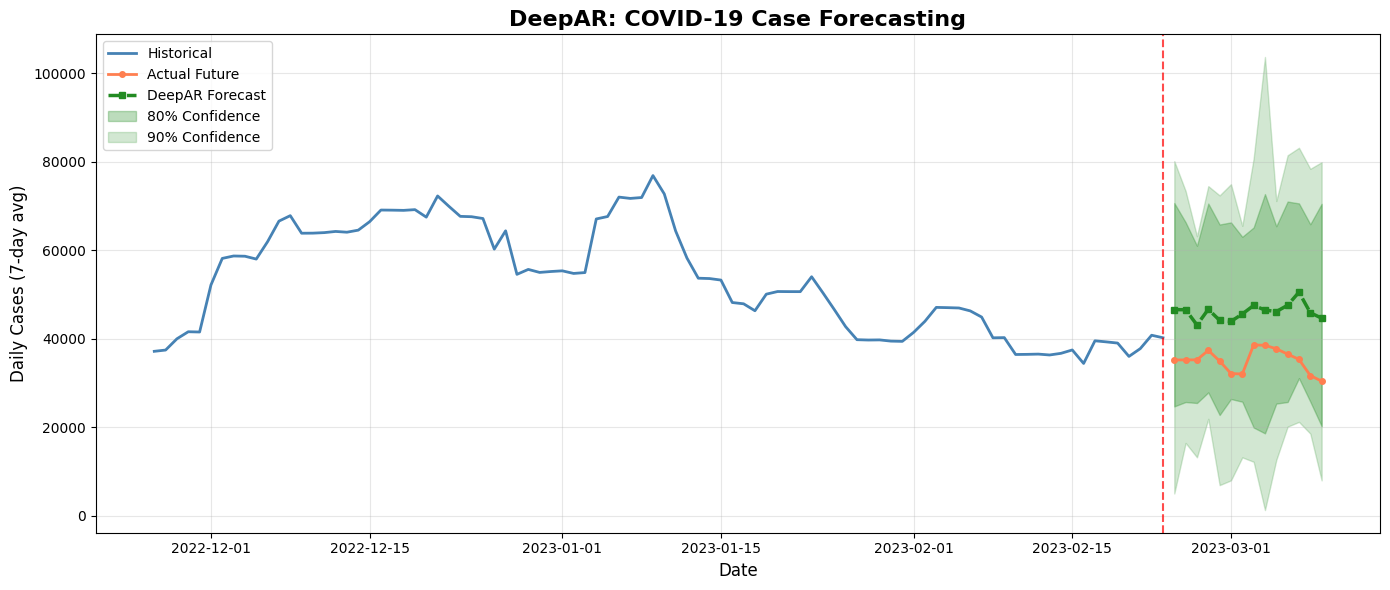


👆 DeepAR captures the trend and provides uncertainty bounds!


In [7]:
plt.figure(figsize=(14, 6))

# Historical data
train_dates = train_df['Date'].values[-90:]  # Last 3 months for context
train_values = train_df[data['target']].values[-90:]
plt.plot(train_dates, train_values, label='Historical', color='steelblue', linewidth=2)

# Forecast dates
last_train_date = pd.Timestamp(train_dates[-1])
forecast_dates = pd.date_range(start=last_train_date + pd.Timedelta(days=1), periods=14, freq='D')
actual_values = actual[-14:]

# Actual future
plt.plot(forecast_dates, actual_values, label='Actual Future', 
         color='coral', linewidth=2, marker='o', markersize=4)

# DeepAR prediction
plt.plot(forecast_dates, deepar_forecast.mean, label='DeepAR Forecast', 
         color='forestgreen', linewidth=2.5, marker='s', markersize=5, linestyle='--')

# Confidence intervals
plt.fill_between(forecast_dates, deepar_forecast.quantile(0.1), deepar_forecast.quantile(0.9),
                 alpha=0.3, color='forestgreen', label='80% Confidence')
plt.fill_between(forecast_dates, deepar_forecast.quantile(0.05), deepar_forecast.quantile(0.95),
                 alpha=0.2, color='forestgreen', label='90% Confidence')

plt.axvline(x=last_train_date, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
plt.title('DeepAR: COVID-19 Case Forecasting', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily Cases (7-day avg)', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n👆 DeepAR captures the trend and provides uncertainty bounds!")

## Evaluate DeepAR Performance

In [8]:
# Calculate metrics
deepar_metrics = calculate_metrics(deepar_forecast.mean, actual_values)

print("\n📊 DeepAR Performance Metrics:")
print("=" * 50)
print(f"  MAE (Mean Absolute Error):     {deepar_metrics['mae']:,.2f}")
print(f"  RMSE (Root Mean Squared Error): {deepar_metrics['rmse']:,.2f}")
print(f"  MAPE (Mean Absolute % Error):   {deepar_metrics['mape']:.2f}%")
print("=" * 50)

if deepar_metrics['mape'] < 15:
    print("\n✨ Excellent! DeepAR is handling the COVID patterns well!")
elif deepar_metrics['mape'] < 25:
    print("\n👍 Good performance! DeepAR captured the main trends.")
else:
    print("\n📝 Decent baseline. Consider tuning parameters for better results.")


📊 DeepAR Performance Metrics:
  MAE (Mean Absolute Error):     11,020.53
  RMSE (Root Mean Squared Error): 11,282.10
  MAPE (Mean Absolute % Error):   31.97%

📝 Decent baseline. Consider tuning parameters for better results.


---

# Part 2: SimpleFeedForward - The Fast Baseline

SimpleFeedForward is exactly what it sounds like - a simple neural network without fancy recurrent connections. But don't underestimate it!

## When to Use SimpleFeedForward

✅ Use SimpleFeedForward when you need:
- **Fast training** (10x faster than DeepAR)
- **Quick experiments** (test ideas rapidly)
- **Stable trends** (works well when patterns don't shift much)
- **A baseline** (always compare your fancy model to this!)

## Key Differences from DeepAR

| Aspect | DeepAR | SimpleFeedForward |
|--------|--------|-------------------|
| Architecture | RNN (remembers past) | Feedforward (no memory) |
| Training Speed | Slower (1-5 min) | Fast (10-30 sec) |
| Best For | Complex patterns | Stable trends |
| Parameters | More to tune | Fewer, simpler |

## Configure SimpleFeedForward

In [9]:
# SimpleFeedForward configuration
feedforward_estimator = SimpleFeedForwardEstimator(
    prediction_length=14,
    context_length=60,
    
    # Network architecture (simpler than DeepAR)
    hidden_dimensions=[40, 40],            # Two hidden layers (note: hidden_dimensions, not hidden_dims!)
    
    # Training settings (more epochs since it's fast)
    lr=0.001,
    batch_size=32,
    num_batches_per_epoch=50,
    trainer_kwargs={"max_epochs": 20}
)

print("✓ SimpleFeedForward configured!")
print(f"\nConfiguration:")
print(f"  • Prediction length: 14 days")
print(f"  • Context length: 60 days")
print(f"  • Hidden layers: {feedforward_estimator.hidden_dimensions}")
print(f"  • Learning rate: {feedforward_estimator.lr}")
print(f"  • Training epochs: 20")
print("\nNote: SimpleFeedForward is a simple baseline model.")
print("It doesn't use freq or external features like DeepAR does.")

✓ SimpleFeedForward configured!

Configuration:
  • Prediction length: 14 days
  • Context length: 60 days
  • Hidden layers: [40, 40]
  • Learning rate: 0.001
  • Training epochs: 20

Note: SimpleFeedForward is a simple baseline model.
It doesn't use freq or external features like DeepAR does.


## Train SimpleFeedForward

Watch how fast this trains compared to DeepAR!

In [10]:
import time

print("🏃 Training SimpleFeedForward (this should be quick!)...\n")

start_time = time.time()
feedforward_predictor = feedforward_estimator.train(train_ds)
training_time = time.time() - start_time

print(f"\n✓ Training complete in {training_time:.1f} seconds!")
print(f"   (Told you it was fast! 😊)")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs

  | Name  | Type                   | Params
-------------------------------------------------
0 | model | SimpleFeedForwardModel | 25.5 K
-------------------------------------------------
25.5 K    Trainable params
0         Non-trainable params
25.5 K    Total params
0.102     Total estimated model params size (MB)


🏃 Training SimpleFeedForward (this should be quick!)...



Training: |                                                                                    | 0/? [00:00<?,…

Epoch 0, global step 50: 'train_loss' reached 12.32378 (best 12.32378), saving model to '/workspace/lightning_logs/version_5/checkpoints/epoch=0-step=50.ckpt' as top 1
Epoch 1, global step 100: 'train_loss' reached 11.09987 (best 11.09987), saving model to '/workspace/lightning_logs/version_5/checkpoints/epoch=1-step=100.ckpt' as top 1
Epoch 2, global step 150: 'train_loss' reached 10.81237 (best 10.81237), saving model to '/workspace/lightning_logs/version_5/checkpoints/epoch=2-step=150.ckpt' as top 1
Epoch 3, global step 200: 'train_loss' reached 10.69291 (best 10.69291), saving model to '/workspace/lightning_logs/version_5/checkpoints/epoch=3-step=200.ckpt' as top 1
Epoch 4, global step 250: 'train_loss' was not in top 1
Epoch 5, global step 300: 'train_loss' was not in top 1
Epoch 6, global step 350: 'train_loss' was not in top 1
Epoch 7, global step 400: 'train_loss' reached 10.57306 (best 10.57306), saving model to '/workspace/lightning_logs/version_5/checkpoints/epoch=7-step=400


✓ Training complete in 3.0 seconds!
   (Told you it was fast! 😊)


## Generate SimpleFeedForward Forecasts

In [11]:
print("🔮 Generating SimpleFeedForward forecasts...")

forecast_it, ts_it = make_evaluation_predictions(
    dataset=test_ds,
    predictor=feedforward_predictor,
    num_samples=100
)

forecasts = list(forecast_it)
ff_forecast = forecasts[0]

print("✓ Forecasts generated!")
print(f"\n📊 Forecast Summary:")
print(f"  Mean prediction: {ff_forecast.mean.mean():.0f} cases/day")
print(f"  Forecast range: {ff_forecast.mean.min():.0f} to {ff_forecast.mean.max():.0f}")

🔮 Generating SimpleFeedForward forecasts...
✓ Forecasts generated!

📊 Forecast Summary:
  Mean prediction: 43014 cases/day
  Forecast range: 40762 to 44468


## Visualize SimpleFeedForward Predictions

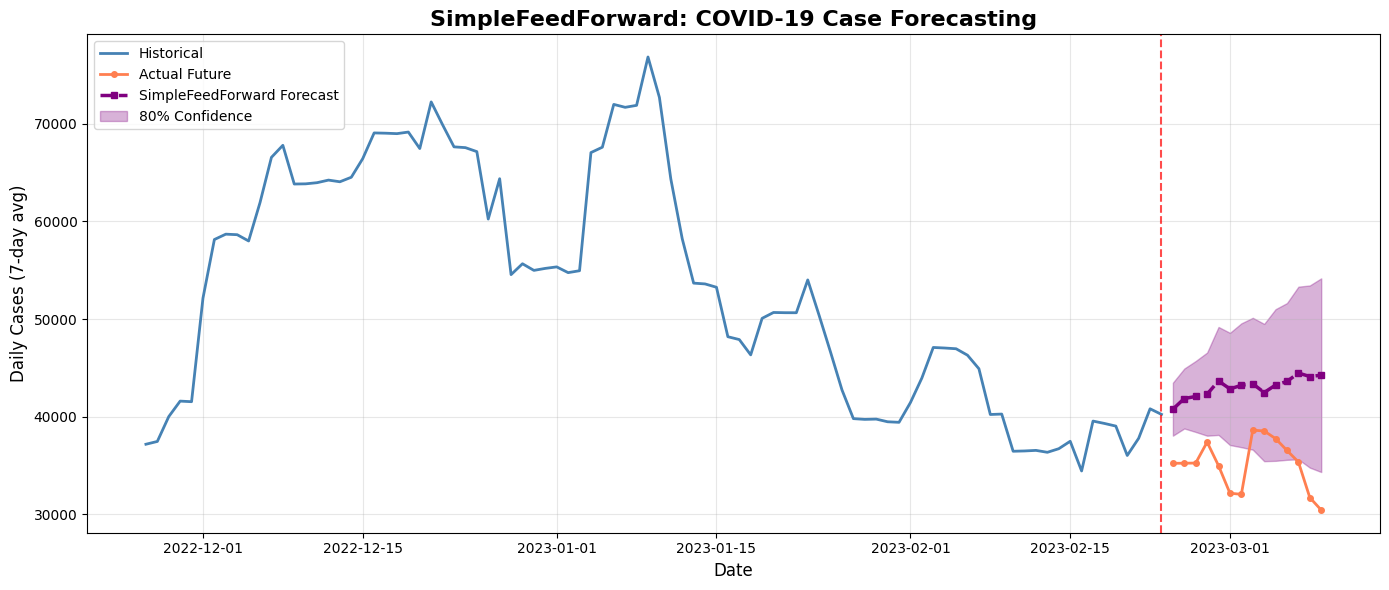


👆 SimpleFeedForward gives a smooth baseline forecast!


In [12]:
plt.figure(figsize=(14, 6))

# Historical
plt.plot(train_dates, train_values, label='Historical', color='steelblue', linewidth=2)

# Actual
plt.plot(forecast_dates, actual_values, label='Actual Future', 
         color='coral', linewidth=2, marker='o', markersize=4)

# SimpleFeedForward prediction
plt.plot(forecast_dates, ff_forecast.mean, label='SimpleFeedForward Forecast', 
         color='purple', linewidth=2.5, marker='s', markersize=5, linestyle='--')

# Confidence intervals
plt.fill_between(forecast_dates, ff_forecast.quantile(0.1), ff_forecast.quantile(0.9),
                 alpha=0.3, color='purple', label='80% Confidence')

plt.axvline(x=last_train_date, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
plt.title('SimpleFeedForward: COVID-19 Case Forecasting', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily Cases (7-day avg)', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n👆 SimpleFeedForward gives a smooth baseline forecast!")

## Evaluate SimpleFeedForward Performance

In [13]:
ff_metrics = calculate_metrics(ff_forecast.mean, actual_values)

print("\n📊 SimpleFeedForward Performance Metrics:")
print("=" * 50)
print(f"  MAE:  {ff_metrics['mae']:,.2f}")
print(f"  RMSE: {ff_metrics['rmse']:,.2f}")
print(f"  MAPE: {ff_metrics['mape']:.2f}%")
print("=" * 50)
print(f"  Training time: {training_time:.1f} seconds")
print("=" * 50)


📊 SimpleFeedForward Performance Metrics:
  MAE:  7,934.96
  RMSE: 8,479.86
  MAPE: 23.35%
  Training time: 3.0 seconds


---

# Part 3: DeepNPTS - The Flexible One

DeepNPTS (Deep Non-Parametric Time Series) is special - it doesn't assume your data follows any specific distribution (like normal or Poisson). Instead, it learns the distribution directly from your data.

## When to Use DeepNPTS

✅ Use DeepNPTS when you have:
- **Shifting distributions** (like COVID waves changing patterns)
- **Unusual data** (not normal distribution)
- **Regime changes** (data behavior changes over time)
- **Heavy tails** (rare extreme events)

## Why It's Different

Most models assume your data follows a specific mathematical distribution. DeepNPTS says: "I'll learn the distribution from the data itself!" This makes it flexible for COVID data where each wave behaves differently.

## Configure DeepNPTS

In [14]:
# DeepNPTS configuration
deepnpts_estimator = DeepNPTSEstimator(
    freq='D',
    prediction_length=14,
    context_length=60,
    num_feat_dynamic_real=num_features,
    
    # Network architecture
    num_hidden_nodes=[40],                # Single hidden layer
    dropout_rate=0.1,
    
    # Training settings
    lr=0.001,
    epochs=15,                             # DeepNPTS accepts epochs directly!
    batch_size=32,
    num_batches_per_epoch=50
)

print("✓ DeepNPTS configured!")
print(f"\nConfiguration:")
print(f"  • Frequency: {deepnpts_estimator.freq}")
print(f"  • Prediction length: 14 days")
print(f"  • Context length: 60 days")
print(f"  • Features: {deepnpts_estimator.num_feat_dynamic_real}")
print(f"  • Hidden nodes: {deepnpts_estimator.num_hidden_nodes}")
print(f"  • Dropout: {deepnpts_estimator.dropout_rate}")
print(f"  • Learning rate: {deepnpts_estimator.lr}")
print(f"  • Training epochs: {deepnpts_estimator.epochs}")
print("\nNote: DeepNPTS uniquely accepts 'epochs' as a direct parameter!")

✓ DeepNPTS configured!

Configuration:
  • Frequency: D
  • Prediction length: 14 days
  • Context length: 60 days
  • Features: 3
  • Hidden nodes: [40]
  • Dropout: 0.1
  • Learning rate: 0.001
  • Training epochs: 15

Note: DeepNPTS uniquely accepts 'epochs' as a direct parameter!


## Train DeepNPTS

In [15]:
print("🚀 Training DeepNPTS on COVID-19 data...")
print("(Learning the distribution directly from the data)\n")

deepnpts_predictor = deepnpts_estimator.train(train_ds)

print("\n✓ Training complete!")

🚀 Training DeepNPTS on COVID-19 data...
(Learning the distribution directly from the data)

Loss for epoch 0: 10784.5799609375
Loss for epoch 1: 6711.854873046875
Loss for epoch 2: 6221.471201171875
Loss for epoch 3: 4661.5538403320315
Loss for epoch 4: 3300.9157775878907
Loss for epoch 5: 3433.6784375
Loss for epoch 6: 2880.498889160156
Loss for epoch 7: 2326.987490234375
Loss for epoch 8: 2354.46955078125
Loss for epoch 9: 1998.1128173828124
Loss for epoch 10: 2064.061834716797
Loss for epoch 11: 1824.9320764160157
Loss for epoch 12: 1501.3050231933594
Loss for epoch 13: 1534.9713958740235
Loss for epoch 14: 1679.2469226074218
Best loss: 1501.3050231933594

✓ Training complete!


## Generate DeepNPTS Forecasts

In [16]:
print("🔮 Generating DeepNPTS forecasts...")

forecast_it, ts_it = make_evaluation_predictions(
    dataset=test_ds,
    predictor=deepnpts_predictor,
    num_samples=100
)

forecasts = list(forecast_it)
npts_forecast = forecasts[0]

print("✓ Forecasts generated!")
print(f"\n📊 Forecast Summary:")
print(f"  Mean prediction: {npts_forecast.mean.mean():.0f} cases/day")
print(f"  Forecast range: {npts_forecast.mean.min():.0f} to {npts_forecast.mean.max():.0f}")

🔮 Generating DeepNPTS forecasts...
✓ Forecasts generated!

📊 Forecast Summary:
  Mean prediction: 40325 cases/day
  Forecast range: 40320 to 40326


## Visualize DeepNPTS Predictions

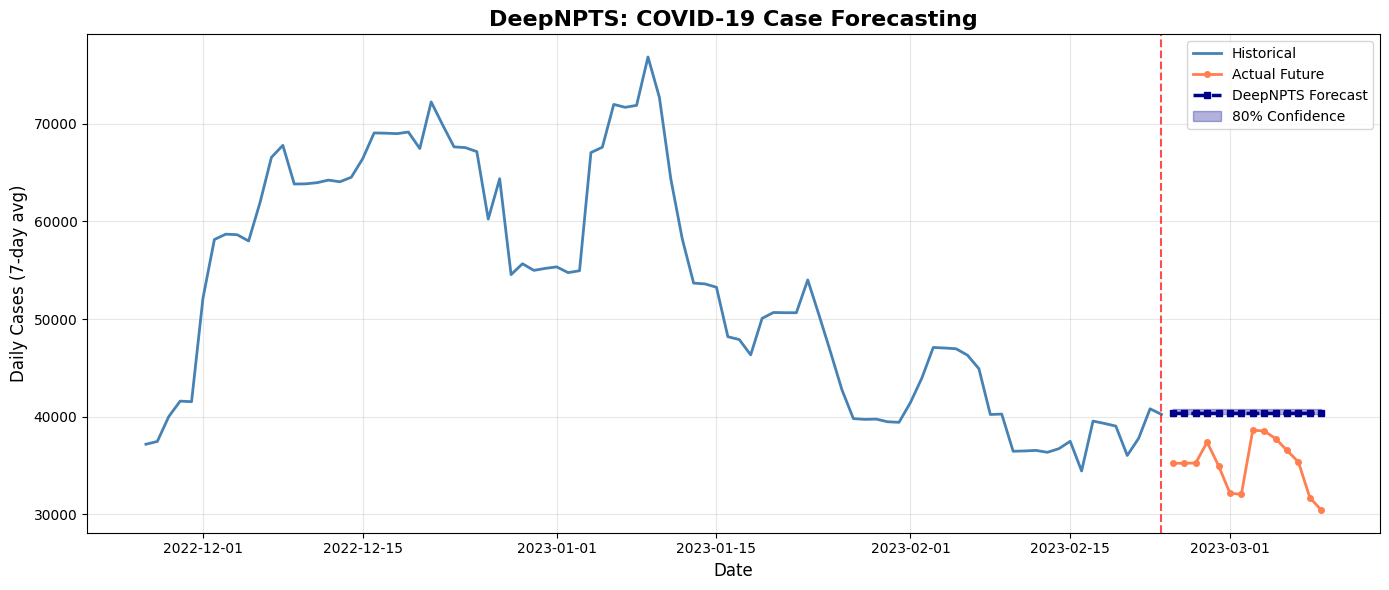


👆 DeepNPTS adapts to the data's natural distribution!


In [17]:
plt.figure(figsize=(14, 6))

# Historical
plt.plot(train_dates, train_values, label='Historical', color='steelblue', linewidth=2)

# Actual
plt.plot(forecast_dates, actual_values, label='Actual Future', 
         color='coral', linewidth=2, marker='o', markersize=4)

# DeepNPTS prediction
plt.plot(forecast_dates, npts_forecast.mean, label='DeepNPTS Forecast', 
         color='darkblue', linewidth=2.5, marker='s', markersize=5, linestyle='--')

# Confidence intervals
plt.fill_between(forecast_dates, npts_forecast.quantile(0.1), npts_forecast.quantile(0.9),
                 alpha=0.3, color='darkblue', label='80% Confidence')

plt.axvline(x=last_train_date, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
plt.title('DeepNPTS: COVID-19 Case Forecasting', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily Cases (7-day avg)', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n👆 DeepNPTS adapts to the data's natural distribution!")

## Evaluate DeepNPTS Performance

In [18]:
npts_metrics = calculate_metrics(npts_forecast.mean, actual_values)

print("\n📊 DeepNPTS Performance Metrics:")
print("=" * 50)
print(f"  MAE:  {npts_metrics['mae']:,.2f}")
print(f"  RMSE: {npts_metrics['rmse']:,.2f}")
print(f"  MAPE: {npts_metrics['mape']:.2f}%")
print("=" * 50)


📊 DeepNPTS Performance Metrics:
  MAE:  5,246.77
  RMSE: 5,827.40
  MAPE: 15.58%


---

# Quick Comparison: Which Model Should You Choose?

Let's compare all three models side by side!

In [19]:
# Create comparison table
comparison = pd.DataFrame([
    {'Model': 'DeepAR', 'MAPE (%)': deepar_metrics['mape'], 
     'MAE': deepar_metrics['mae'], 'RMSE': deepar_metrics['rmse']},
    {'Model': 'SimpleFeedForward', 'MAPE (%)': ff_metrics['mape'], 
     'MAE': ff_metrics['mae'], 'RMSE': ff_metrics['rmse']},
    {'Model': 'DeepNPTS', 'MAPE (%)': npts_metrics['mape'], 
     'MAE': npts_metrics['mae'], 'RMSE': npts_metrics['rmse']}
])

comparison = comparison.sort_values('MAPE (%)')
comparison.insert(0, 'Rank', [1, 2, 3])

print("\n" + "=" * 70)
print("🏆 MODEL COMPARISON")
print("=" * 70)
print(comparison.to_string(index=False))
print("=" * 70)

winner = comparison.iloc[0]['Model']
print(f"\n🥇 Winner: {winner}!")
print("\nNote: These results are from a quick training demo.")
print("For production, train with more epochs and tune hyperparameters!")


🏆 MODEL COMPARISON
 Rank             Model  MAPE (%)          MAE         RMSE
    1          DeepNPTS 15.578398  5246.766602  5827.403809
    2 SimpleFeedForward 23.351792  7934.958496  8479.861328
    3            DeepAR 31.967419 11020.529297 11282.095703

🥇 Winner: DeepNPTS!

Note: These results are from a quick training demo.
For production, train with more epochs and tune hyperparameters!


---

# Summary: Decision Guide

Now you know how to use all three GluonTS models! Here's a quick guide for choosing:

## 🎯 Choose DeepAR When:
- You have **complex temporal patterns** (multiple waves, cycles)
- You need to capture **long-term dependencies**
- You have **seasonality** (daily, weekly, monthly patterns)
- Accuracy is more important than speed

## 🎯 Choose SimpleFeedForward When:
- You need **fast training** for experimentation
- Your data has **stable, smooth trends**
- You want a **baseline** to compare against
- You need quick retraining in production

## 🎯 Choose DeepNPTS When:
- Your data has **shifting distributions**
- You see **regime changes** (behavior changes over time)
- You have **unusual distributions** (not normal)
- You want flexibility without distribution assumptions

---

## Next Steps

Want to see a complete COVID-19 forecasting application? Check out:
- **`GluonTS.example.ipynb`** - Full pipeline with model comparison, uncertainty quantification, and scenario analysis

Want to learn more about the parameters?
- **`GluonTS.API.md`** - Detailed API documentation

---

**Happy forecasting! 🚀**